# Classification Track (Part A) — Adult Census Income Prediction
### 23CSE301 Machine Learning Capstone — Review 1

**Dataset:** UCI Adult / Census Income dataset (`adult.data` + `adult.test` merged) — 48,842 records of U.S. census respondents.

**Goal:** Predict whether a person's annual income exceeds $50K (`income`: `<=50K` / `>50K`) from demographic and employment features.

**Scope note:** Per the course guidelines, Classification Part A (Review 1) covers the first 5 algorithms — Logistic Regression, KNN,
Naive Bayes, Decision Tree, and SVM. Part B (Random Forest, AdaBoost, Gradient Boosting, Bagging, MLP) and the consolidated 10-algorithm
table are Review 2 scope and are not included here.

All random operations use `random_state=42` for reproducibility.

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Shared infrastructure used across every algorithm below (splitting, preprocessing, tuning, scoring).
# Each individual algorithm's own class is imported right where that algorithm is used, not here.
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import (accuracy_score, f1_score, precision_score, recall_score,
                              roc_auc_score, confusion_matrix, ConfusionMatrixDisplay, roc_curve)

RANDOM_STATE = 42
sns.set_theme(style='whitegrid', palette='colorblind')
plt.rcParams['figure.dpi'] = 100

## Section A — Dataset Loading & Exploratory Data Analysis

### A1. Dataset Loading & Audit

**Note on missing values:** the raw UCI Adult files mark missing entries with the literal string `?` rather than leaving the
field blank. `na_values=['?']` tells `pandas` to parse those cells as genuine `NaN` on load, so `.isna().sum()` below correctly reports
them as missing instead of silently treating `"?"` as a valid category value.

In [2]:
df = pd.read_csv('../data/adult.csv', na_values=['?'])
print("Shape:", df.shape)
df.head()

Shape: (48842, 15)


,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


In [3]:
print("Data types:\n")
print(df.dtypes)
print("\nMissing values per column:\n")
print(df.isna().sum())
print("\nDuplicate rows:", df.duplicated().sum())

Data types:

age               int64
workclass           str
fnlwgt            int64
education           str
education-num     int64
marital-status      str
occupation          str
relationship        str
race                str
sex                 str
capital-gain      int64
capital-loss      int64
hours-per-week    int64
native-country      str
income              str
dtype: object

Missing values per column:

age                  0
workclass         2799
fnlwgt               0
education            0
education-num        0
marital-status       0
occupation        2809
relationship         0
race                 0
sex                  0
capital-gain         0
capital-loss         0
hours-per-week       0
native-country     857
income               0
dtype: int64

Duplicate rows: 52


In [4]:
print("Target ('income') class distribution:\n")
print(df['income'].value_counts())
print()
print(df['income'].value_counts(normalize=True).round(4))

Target ('income') class distribution:

income
<=50K    37155
>50K     11687
Name: count, dtype: int64

income
<=50K    0.7607
>50K     0.2393
Name: proportion, dtype: float64


**Observation:** 48,842 rows, 15 columns. Three categorical columns (`workclass`, `occupation`, `native-country`) contain missing
values (originally encoded as `?` in the raw files) — around 5–6% of rows are affected. There are 52 exact duplicate rows. The target is
**imbalanced**: ~76% earn `<=50K` vs. ~24% earn `>50K`, which is why we use a **stratified** train/test split and report **weighted** F1/
Precision/Recall (accuracy alone would be misleading on an imbalanced target).

### A2. EDA Visualisations

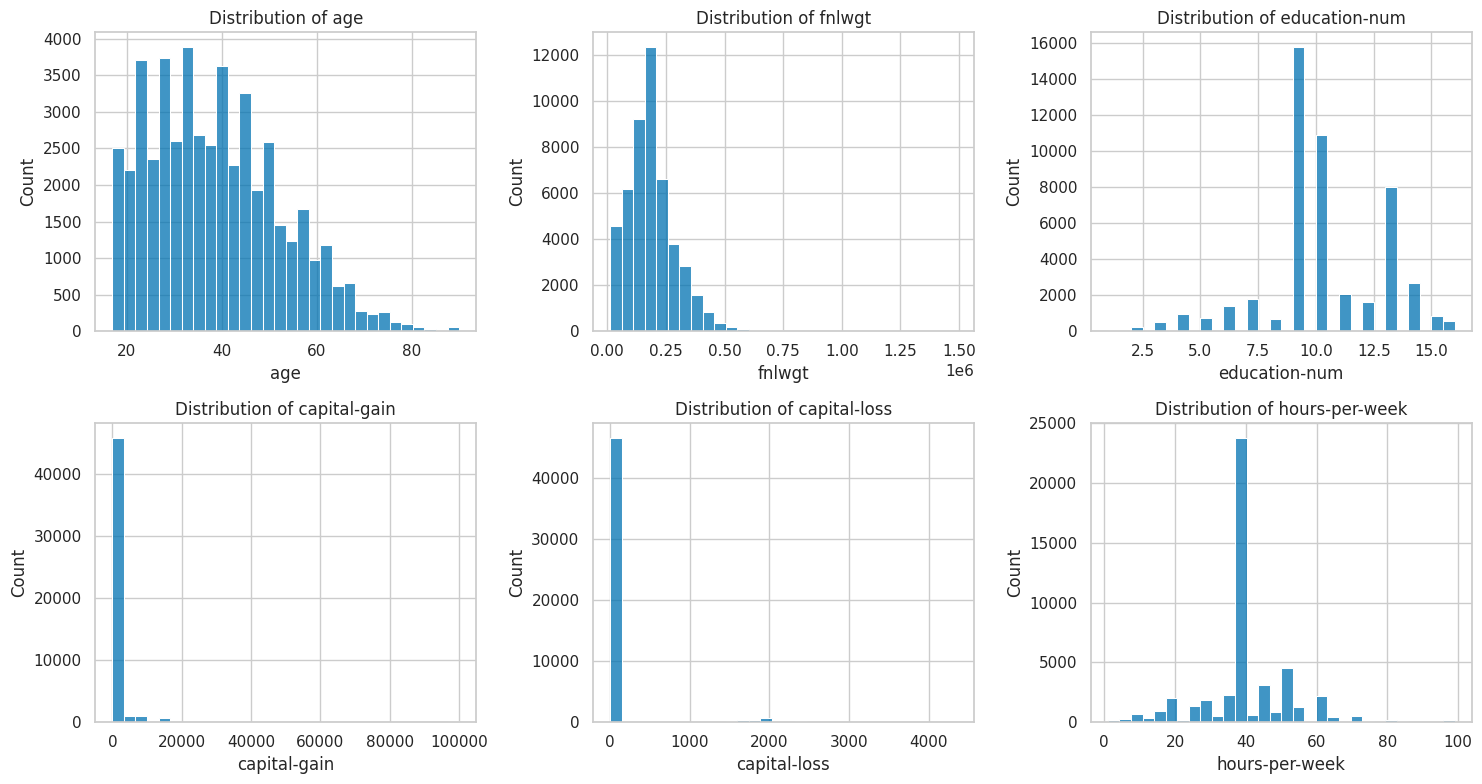

In [5]:
numeric_dist_cols = ['age','fnlwgt','education-num','capital-gain','capital-loss','hours-per-week']
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.ravel()
for i, col in enumerate(numeric_dist_cols):
    sns.histplot(df[col], bins=30, ax=axes[i], color='#0072B2')
    axes[i].set_title(f'Distribution of {col}')
plt.tight_layout()
plt.savefig('clf_feature_distributions.png', bbox_inches='tight')
plt.show()

**Insight:** `capital-gain` and `capital-loss` are extremely sparse (mostly 0, with a long tail of large values) — most respondents
report no capital gains/losses at all. `age` is right-skewed towards younger adults. `hours-per-week` is heavily concentrated at 40
(standard full-time week) with some outliers near 0 and near 99.

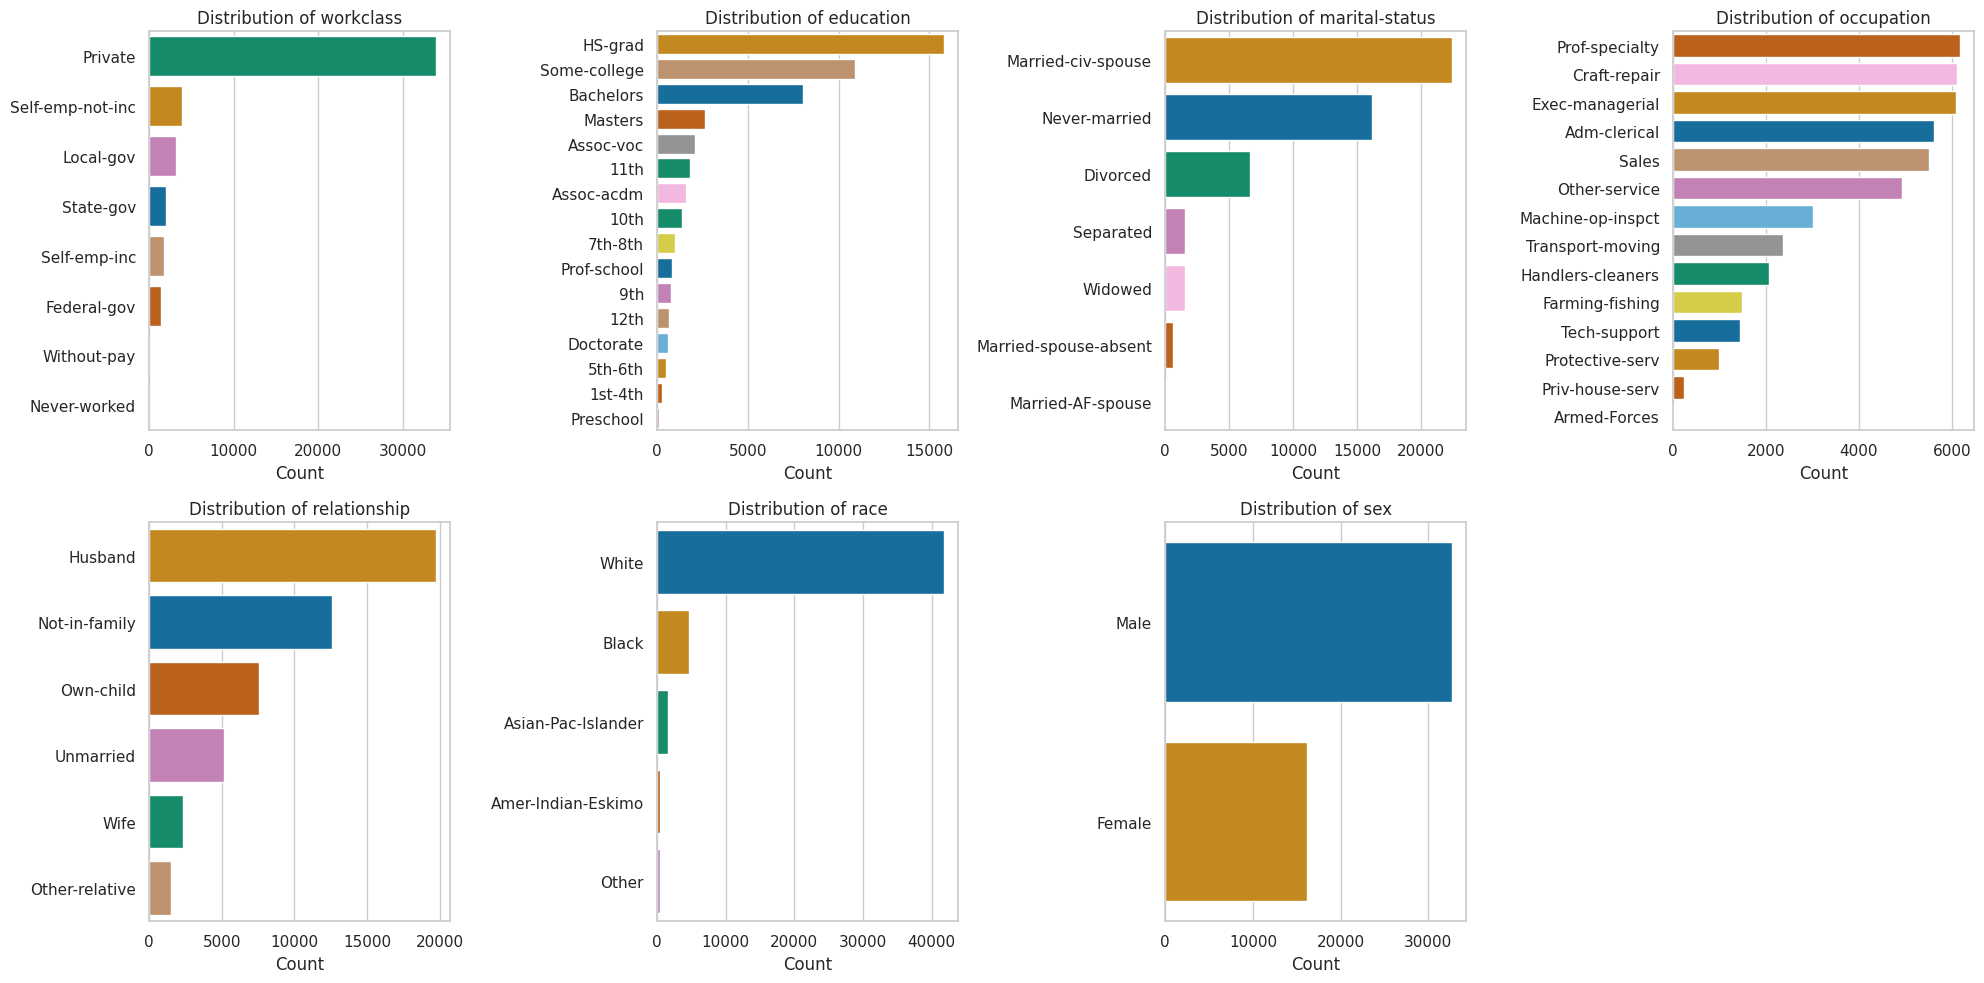

In [6]:
categorical_dist_cols = ['workclass', 'education', 'marital-status', 'occupation', 'relationship', 'race', 'sex']
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.ravel()
for i, col in enumerate(categorical_dist_cols):
    order = df[col].value_counts().index
    sns.countplot(data=df, y=col, order=order, hue=col, palette='colorblind', legend=False, ax=axes[i])
    axes[i].set_title(f'Distribution of {col}')
    axes[i].set_xlabel('Count'); axes[i].set_ylabel('')
axes[-1].axis('off')  # unused 8th slot
plt.tight_layout()
plt.savefig('clf_categorical_distributions.png', bbox_inches='tight')
plt.show()

**Insight:** `workclass` and `occupation` are dominated by `Private`/a handful of common occupations, `education` peaks at
`HS-grad` and `Some-college`, `marital-status` is bimodal (Never-married vs. Married-civ-spouse), and `sex`/`race` are both heavily
imbalanced (more male, more White respondents) — a reminder that any fairness-sensitive conclusions from this dataset should be read
with that skew in mind.

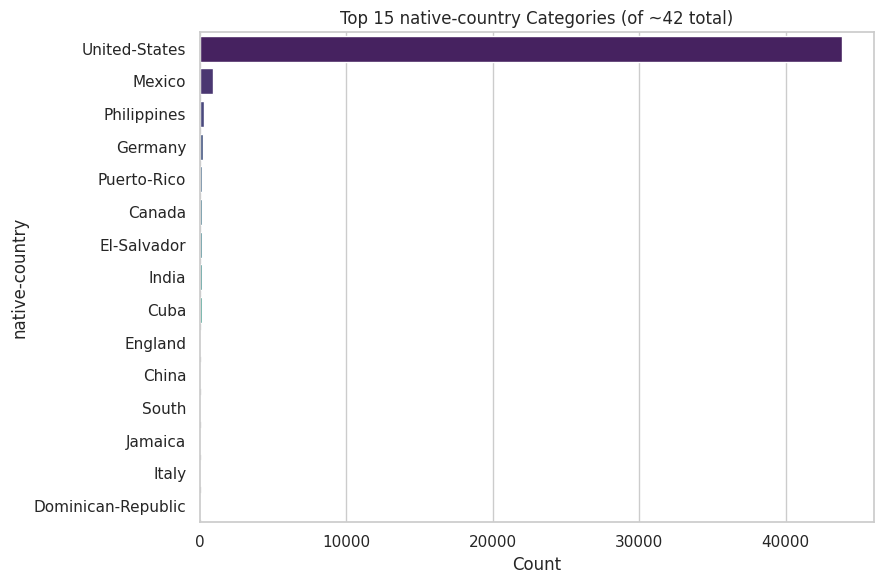

In [7]:
top_countries = df['native-country'].value_counts().head(15)
plt.figure(figsize=(9, 6))
sns.barplot(x=top_countries.values, y=top_countries.index, hue=top_countries.index, palette='viridis', legend=False)
plt.title('Top 15 native-country Categories (of ~42 total)')
plt.xlabel('Count'); plt.ylabel('native-country')
plt.tight_layout()
plt.savefig('clf_native_country_distribution.png', bbox_inches='tight')
plt.show()

**Insight:** `native-country` is extremely dominated by `United-States` (~90% of records); the ~40 remaining countries are shown
as a horizontal bar of the top 15 because a standard vertical/pie chart across all ~42 categories would be unreadable. This extreme
imbalance is also why the OneHotEncoder later uses `handle_unknown='ignore'` — a rare country seen only in the test split should not
break the pipeline.

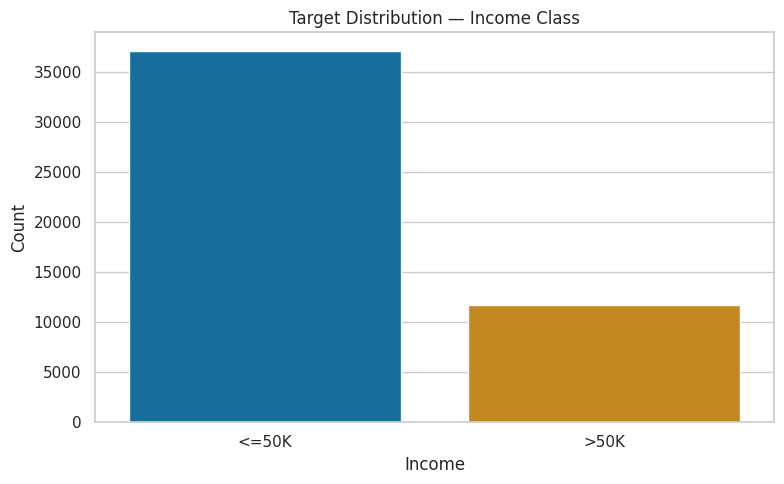

In [8]:
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='income', hue='income', palette='colorblind', legend=False)
plt.title('Target Distribution — Income Class')
plt.xlabel('Income'); plt.ylabel('Count')
plt.tight_layout()
plt.savefig('clf_target_distribution.png', bbox_inches='tight')
plt.show()

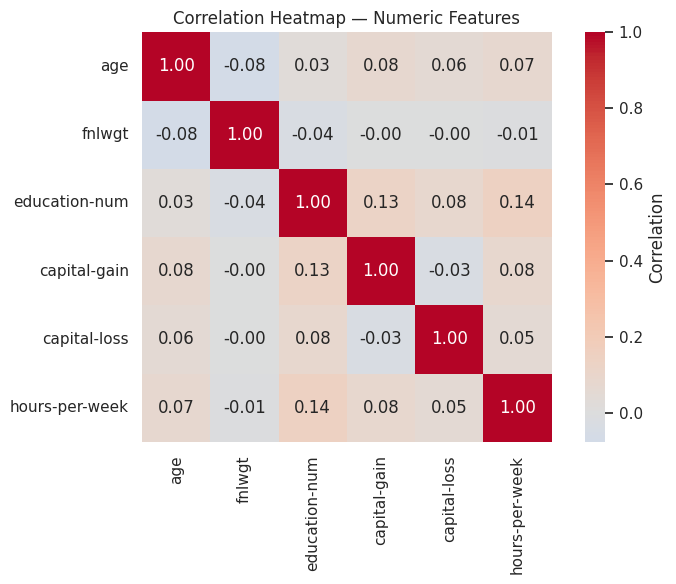

In [9]:
plt.figure(figsize=(8, 6))
corr = df[numeric_dist_cols].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, square=True, cbar_kws={'label':'Correlation'})
plt.title('Correlation Heatmap — Numeric Features')
plt.tight_layout()
plt.savefig('clf_correlation_heatmap.png', bbox_inches='tight')
plt.show()

**Insight:** Numeric features are only weakly correlated with each other (no strong multicollinearity issue), meaning most of the
predictive signal for income will need to come from the categorical features (occupation, marital-status, education) rather than a couple
of dominant numeric predictors.

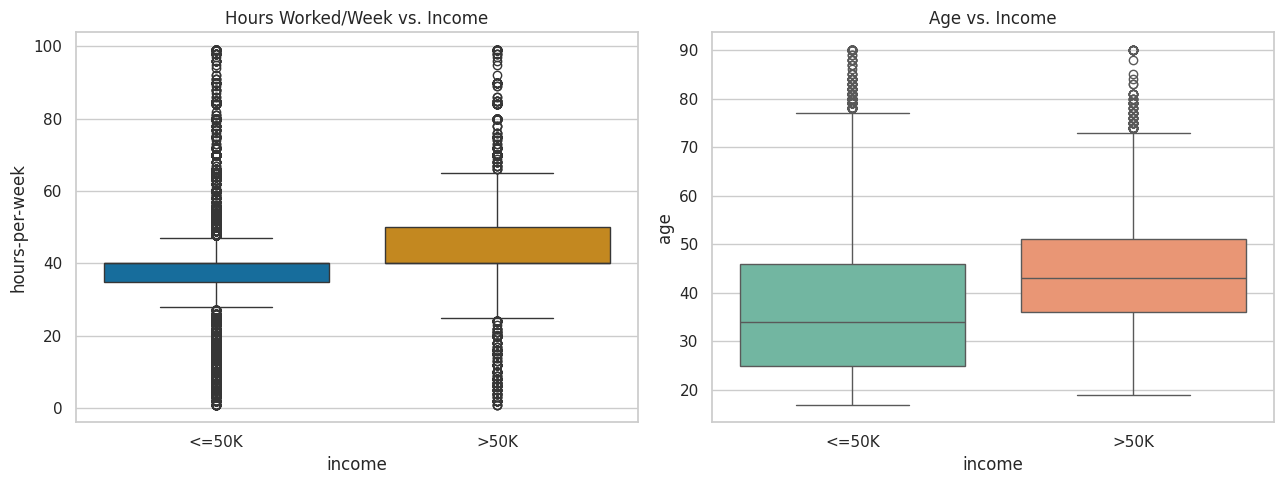

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
sns.boxplot(data=df, x='income', y='hours-per-week', hue='income', palette='colorblind', ax=axes[0], legend=False)
axes[0].set_title('Hours Worked/Week vs. Income')

sns.boxplot(data=df, x='income', y='age', hue='income', palette='Set2', ax=axes[1], legend=False)
axes[1].set_title('Age vs. Income')
plt.tight_layout()
plt.savefig('clf_boxplot_feature_target.png', bbox_inches='tight')
plt.show()

**Insight:** Both `hours-per-week` and `age` are visibly higher on average for the `>50K` group — high earners tend to work more
hours and be somewhat older (peak earning years), giving these two numeric features real discriminative power despite their weak pairwise
correlations seen above. The scatter plots below show the same two relationships as literal x-y scatter plots.

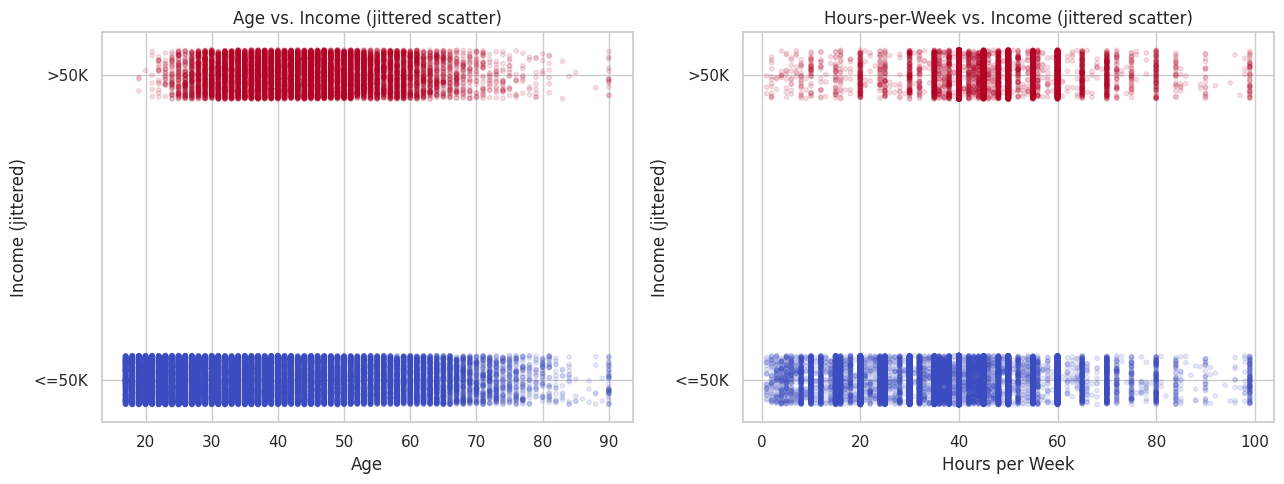

In [11]:
# income is binary, so a plain scatter against it would collapse into two flat lines at y=0 and y=1.
# A small uniform jitter on the (numeric) target reveals point density while keeping both axes genuinely numeric/continuous.
rng = np.random.RandomState(RANDOM_STATE)
income_numeric = (df['income'] == '>50K').astype(int)
jitter = rng.uniform(-0.08, 0.08, size=len(df))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].scatter(df['age'], income_numeric + jitter, alpha=0.12, s=10, c=income_numeric, cmap='coolwarm')
axes[0].set_yticks([0, 1]); axes[0].set_yticklabels(['<=50K', '>50K'])
axes[0].set_xlabel('Age'); axes[0].set_ylabel('Income (jittered)')
axes[0].set_title('Age vs. Income (jittered scatter)')

axes[1].scatter(df['hours-per-week'], income_numeric + jitter, alpha=0.12, s=10, c=income_numeric, cmap='coolwarm')
axes[1].set_yticks([0, 1]); axes[1].set_yticklabels(['<=50K', '>50K'])
axes[1].set_xlabel('Hours per Week'); axes[1].set_ylabel('Income (jittered)')
axes[1].set_title('Hours-per-Week vs. Income (jittered scatter)')
plt.tight_layout()
plt.savefig('clf_scatter_feature_target.png', bbox_inches='tight')
plt.show()

**Insight:** Jittering the binary target turns an otherwise-uninformative two-line plot into a readable density picture: the
`>50K` band (top) is visibly thinner and shifted toward older ages and 40+ hour weeks, while the `<=50K` band (bottom) is denser at
younger ages and spread across both shorter and standard work weeks — the same pattern the boxplots above show, now as a literal
feature-vs-target scatter plot.

## Section B — Data Cleaning, Encoding & Feature Engineering

### B1. Data Cleaning

In [12]:
df_clean = df.drop_duplicates().copy()
print(f"Dropped {df.duplicated().sum()} duplicates -> shape: {df_clean.shape}")

# 'education' is a redundant text version of the already-numeric ordinal 'education-num' -> drop to avoid
# redundant/duplicated information going into one-hot encoding.
# 'fnlwgt' is a census sampling weight (not a demographic/economic attribute of the person) -> not predictive, drop.
df_clean = df_clean.drop(columns=['education', 'fnlwgt'])

print("Missing-value strategy: 'workclass', 'occupation', 'native-country' missing values are imputed with the "
      "column mode (most frequent category), fitted on the TRAINING split only (see ColumnTransformer below) "
      "-- this avoids discarding ~5-6% of rows while keeping the imputation leakage-free.")

Dropped 52 duplicates -> shape: (48790, 15)
Missing-value strategy: 'workclass', 'occupation', 'native-country' missing values are imputed with the column mode (most frequent category), fitted on the TRAINING split only (see ColumnTransformer below) -- this avoids discarding ~5-6% of rows while keeping the imputation leakage-free.


**Outlier check:** `hours-per-week` has a small number of extreme values (near 0 and near 99) that are legitimate but very rare.
We clip them to the 1st/99th percentile **computed on the training set only** (after the split, below) rather than deleting rows, so
extreme-but-real cases are retained in a bounded form instead of distorting the scaler.

### B2. Feature Engineering

In [13]:
# capital-gain and capital-loss are both extremely sparse (mostly zero) and never both non-zero for the same person.
# Combining them into a single net signal reduces sparsity and gives the model one informative numeric feature
# instead of two mostly-zero ones.
df_clean['capital_net'] = df_clean['capital-gain'] - df_clean['capital-loss']
df_clean[['capital-gain','capital-loss','capital_net']].describe()

,capital-gain,capital-loss,capital_net
count,48790.000000,48790.000000,48790.000000
mean,1080.217688,87.595573,992.622115
std,7455.905921,403.209129,7479.462491
min,0.000000,0.000000,-4356.000000
25%,0.000000,0.000000,0.000000
50%,0.000000,0.000000,0.000000
75%,0.000000,0.000000,0.000000
max,99999.000000,4356.000000,99999.000000


### B3. Encoding, Scaling & Stratified Train/Test Split

In [14]:
TARGET = 'income'
NUMERIC_COLS = ['age', 'education-num', 'capital-gain', 'capital-loss', 'hours-per-week', 'capital_net']
CATEGORICAL_COLS = ['workclass', 'marital-status', 'occupation', 'relationship', 'race', 'sex', 'native-country']

y = (df_clean[TARGET] == '>50K').astype(int)
X = df_clean.drop(columns=[TARGET])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)
print(f"Train: {X_train.shape}, Test: {X_test.shape}")
print("Train class balance:\n", y_train.value_counts(normalize=True).round(4))
print("Test class balance:\n", y_test.value_counts(normalize=True).round(4))

# Outlier clipping bounds computed on TRAIN ONLY, then applied to both splits (no leakage)
lo, hi = X_train['hours-per-week'].quantile([0.01, 0.99])
X_train['hours-per-week'] = X_train['hours-per-week'].clip(lo, hi)
X_test['hours-per-week'] = X_test['hours-per-week'].clip(lo, hi)
print(f"\n'hours-per-week' clipped to [{lo}, {hi}] using train-set percentiles")

# Each model below gets its OWN fresh preprocessor via this factory function rather than sharing one
# ColumnTransformer instance. A ColumnTransformer is a MUTABLE object: if the same instance were reused
# across multiple Pipelines, calling .fit() for model B would silently re-fit (overwrite) the imputer/
# encoder/scaler that model A's already-fitted Pipeline still points to (Python passes objects by reference).
# This matters concretely here because SVC (below) is deliberately fit on a smaller stratified SUBSAMPLE
# of the training data -- if it shared a preprocessor with the other four models, fitting SVC would quietly
# swap those models' fitted encoder/scaler statistics out from under them. make_preprocessor() prevents that
# by constructing a brand-new, independent ColumnTransformer every time it's called.
def make_preprocessor():
    return ColumnTransformer([
        ('cat', Pipeline([
            ('impute', SimpleImputer(strategy='most_frequent')),
            ('ohe', OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False))
        ]), CATEGORICAL_COLS),
        ('num', StandardScaler(), NUMERIC_COLS)
    ])

Train: (39032, 13), Test: (9758, 13)
Train class balance:
 income
0    0.7606
1    0.2394
Name: proportion, dtype: float64
Test class balance:
 income
0    0.7606
1    0.2394
Name: proportion, dtype: float64

'hours-per-week' clipped to [8.0, 80.0] using train-set percentiles


**Leakage prevention:** the imputer, one-hot encoder and scaler all live inside the `ColumnTransformer` returned by
`make_preprocessor()`, itself nested inside each model's `Pipeline`. Calling `pipeline.fit(X_train, y_train)` fits every preprocessing
step using training-set statistics only; `predict(X_test)` only ever calls `.transform()`. Stratified splitting preserves the ~76/24
class ratio in both train and test.

## Section C — Classification Track, Part A: 5 Algorithms

In [15]:
results = []
fitted_models = {}

def run_model(name, pipeline, Xtr=X_train, ytr=y_train):
    pipeline.fit(Xtr, ytr)
    preds = pipeline.predict(X_test)
    try:
        proba = pipeline.predict_proba(X_test)[:, 1]
    except AttributeError:
        proba = pipeline.decision_function(X_test)
    acc = accuracy_score(y_test, preds)
    f1 = f1_score(y_test, preds, average='weighted')
    prec = precision_score(y_test, preds, average='weighted')
    rec = recall_score(y_test, preds, average='weighted')
    auc = roc_auc_score(y_test, proba)
    cm = confusion_matrix(y_test, preds)
    results.append({'Model': name, 'Accuracy': acc, 'Precision': prec, 'Recall': rec,
                     'F1 (weighted)': f1, 'ROC-AUC': auc})
    fitted_models[name] = pipeline
    return preds, proba, cm

#### Algorithm 1: Logistic Regression

In [16]:
from sklearn.linear_model import LogisticRegression

logreg_preds, logreg_proba, logreg_cm = run_model(
    'Logistic Regression', Pipeline([('pre', make_preprocessor()), ('model', LogisticRegression(max_iter=1000, random_state=RANDOM_STATE))])
)
print("Logistic Regression done.")

Logistic Regression done.


**Baseline interpretation:** Logistic Regression coefficients (in log-odds space) give a directly interpretable baseline —
positive coefficients push toward `>50K`, negative toward `<=50K`. This is the required interpretability baseline noted in the algorithm
table.

#### Algorithm 2: K-Nearest Neighbors

In [17]:
from sklearn.neighbors import KNeighborsClassifier

# KNN -- quick k comparison via cross-validation on the training set (algorithm note: "Tune k; discuss distance metrics")
knn_scores = {}
skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)
for k in [5, 11, 15, 21]:
    pipe = Pipeline([('pre', make_preprocessor()), ('model', KNeighborsClassifier(n_neighbors=k))])
    scores = cross_val_score(pipe, X_train, y_train, cv=skf, scoring='f1_weighted', n_jobs=-1)
    knn_scores[k] = scores.mean()
    print(f"k={k:3d}  mean CV weighted-F1={scores.mean():.4f}")

best_k = max(knn_scores, key=knn_scores.get)
print(f"\nSelected k={best_k} (highest CV weighted-F1)")

knn_preds, knn_proba, knn_cm = run_model('K-Nearest Neighbors', Pipeline([('pre', make_preprocessor()), ('model', KNeighborsClassifier(n_neighbors=best_k))]))
print("KNN done.")

k=  5  mean CV weighted-F1=0.8364


k= 11  mean CV weighted-F1=0.8454


k= 15  mean CV weighted-F1=0.8455


k= 21  mean CV weighted-F1=0.8474

Selected k=21 (highest CV weighted-F1)


KNN done.


**Distance metric note:** KNN uses Euclidean distance by default over the standardised numeric features and one-hot categorical
dummies. Because one-hot dummies are binary (0/1) while scaled numeric features can range further, Euclidean distance implicitly weights
them comparably post-scaling — an important reason `StandardScaler` is applied before KNN rather than after.

#### Algorithm 3: Naive Bayes (Gaussian)

In [18]:
from sklearn.naive_bayes import GaussianNB

nb_preds, nb_proba, nb_cm = run_model('Naive Bayes (Gaussian)', Pipeline([('pre', make_preprocessor()), ('model', GaussianNB())]))
print("Naive Bayes done.")

Naive Bayes done.


**Conditional independence assumption:** Gaussian Naive Bayes assumes every feature is conditionally independent of every other
feature given the class label. This is clearly violated here (e.g. `education-num` and `occupation` are strongly related), which is the
most likely explanation if Naive Bayes underperforms the other four models in the comparison table below — it is included as a fast,
interpretable baseline rather than an expected top performer.

#### Algorithm 4: Decision Tree Classifier

In [19]:
from sklearn.tree import DecisionTreeClassifier

# Decision Tree -- quick max_depth comparison (algorithm note: "Tune max depth; visualise the tree")
depth_scores = {}
for d in [5, 8, 10, 15, None]:
    pipe = Pipeline([('pre', make_preprocessor()), ('model', DecisionTreeClassifier(max_depth=d, random_state=RANDOM_STATE))])
    scores = cross_val_score(pipe, X_train, y_train, cv=skf, scoring='f1_weighted', n_jobs=-1)
    depth_scores[str(d)] = scores.mean()
    print(f"max_depth={str(d):5s} mean CV weighted-F1={scores.mean():.4f}")

best_depth_str = max(depth_scores, key=depth_scores.get)
best_depth = None if best_depth_str == 'None' else int(best_depth_str)
print(f"\nSelected max_depth={best_depth}")

dt_pipe_final = Pipeline([('pre', make_preprocessor()), ('model', DecisionTreeClassifier(max_depth=best_depth, random_state=RANDOM_STATE))])
dt_preds, dt_proba, dt_cm = run_model('Decision Tree', dt_pipe_final)
print("Decision Tree done.")

max_depth=5     mean CV weighted-F1=0.8416


max_depth=8     mean CV weighted-F1=0.8451


max_depth=10    mean CV weighted-F1=0.8459


max_depth=15    mean CV weighted-F1=0.8413


max_depth=None  mean CV weighted-F1=0.8133

Selected max_depth=10


Decision Tree done.


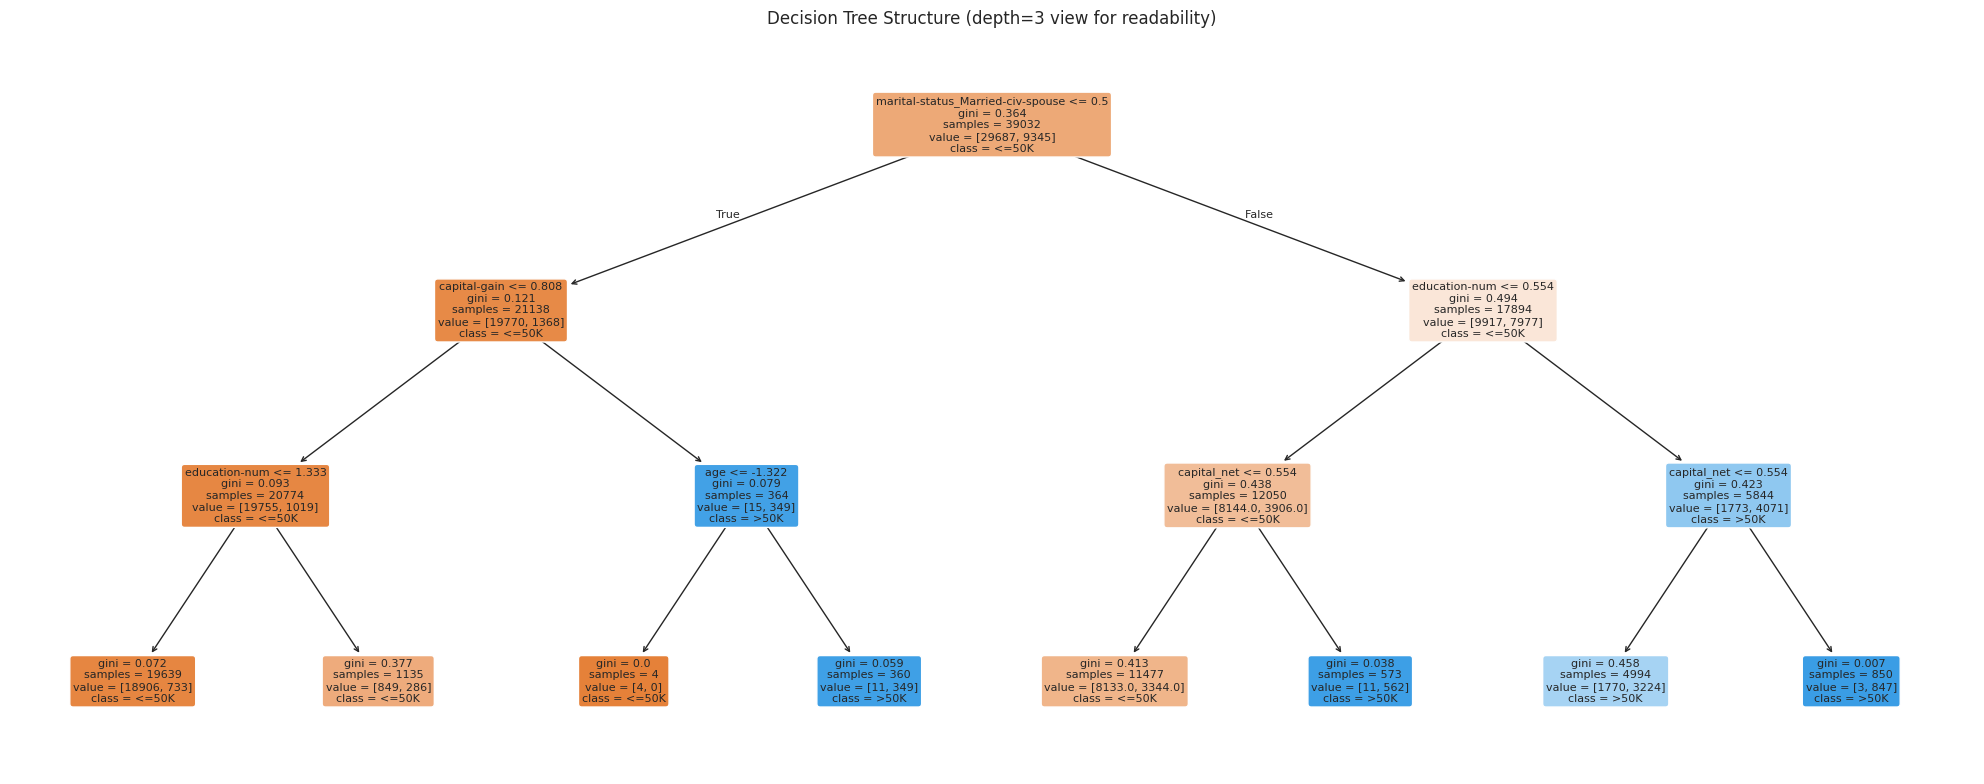

In [20]:
from sklearn.tree import plot_tree, DecisionTreeClassifier

# Visualise the tree (required by algorithm notes) -- shallow depth=3 surrogate purely for visualisation clarity
viz_tree = Pipeline([('pre', make_preprocessor()), ('model', DecisionTreeClassifier(max_depth=3, random_state=RANDOM_STATE))])
viz_tree.fit(X_train, y_train)
feature_names = list(viz_tree.named_steps['pre'].named_transformers_['cat'].named_steps['ohe'].get_feature_names_out(CATEGORICAL_COLS)) + NUMERIC_COLS

plt.figure(figsize=(20, 8))
plot_tree(viz_tree.named_steps['model'], feature_names=feature_names, class_names=['<=50K','>50K'],
          filled=True, rounded=True, fontsize=8, max_depth=3)
plt.title('Decision Tree Structure (depth=3 view for readability)')
plt.tight_layout()
plt.savefig('clf_decision_tree.png', bbox_inches='tight')
plt.show()

**Insight:** `marital-status` (specifically "Married-civ-spouse") and `capital_net`/`education-num` show up as the top splits —
married individuals with higher capital gains and more years of education are far more likely to be classified `>50K`, consistent with
well-known patterns in this dataset.

#### Algorithm 5: Support Vector Machine (SVC)

In [21]:
from sklearn.model_selection import StratifiedShuffleSplit

# SVC on the full ~39k-row training set is computationally impractical (SVM training scales roughly O(n^2) to O(n^3)
# with the RBF kernel). Per standard practice for large datasets, SVC is trained on a stratified random subsample of the
# training set while still being EVALUATED on the full, untouched test set -- this is documented explicitly, not hidden.
sss = StratifiedShuffleSplit(n_splits=1, train_size=8000, random_state=RANDOM_STATE)
sub_idx, _ = next(sss.split(X_train, y_train))
X_train_svc = X_train.iloc[sub_idx]
y_train_svc = y_train.iloc[sub_idx]
print(f"SVC trained on a stratified subsample of {len(X_train_svc)} rows (full train set has {len(X_train)} rows).")

SVC trained on a stratified subsample of 8000 rows (full train set has 39032 rows).


In [22]:
from sklearn.svm import SVC

svc_kernel_scores = {}
for kern in ['linear', 'rbf']:
    pipe = Pipeline([('pre', make_preprocessor()), ('model', SVC(kernel=kern, C=1, random_state=RANDOM_STATE))])
    scores = cross_val_score(pipe, X_train_svc, y_train_svc, cv=3, scoring='f1_weighted', n_jobs=-1)
    svc_kernel_scores[kern] = scores.mean()
    print(f"kernel={kern:7s} mean CV weighted-F1={scores.mean():.4f}")

best_kernel = max(svc_kernel_scores, key=svc_kernel_scores.get)
print(f"\nSelected kernel='{best_kernel}'")

svc_preds, svc_proba, svc_cm = run_model(
    'Support Vector Machine (SVC)',
    Pipeline([('pre', make_preprocessor()), ('model', SVC(kernel=best_kernel, C=1, probability=True, random_state=RANDOM_STATE))]),
    Xtr=X_train_svc, ytr=y_train_svc
)
print("SVC done.")

kernel=linear  mean CV weighted-F1=0.8468


kernel=rbf     mean CV weighted-F1=0.8539

Selected kernel='rbf'


SVC done.


**5-fold cross-validation for the two best-performing models** (per the course's general guideline that CV must be used for at
least the two best-performing models in each track, mirroring what was done for the Regression track):

In [23]:
_prelim_df = pd.DataFrame(results).sort_values('F1 (weighted)', ascending=False)
top2_clf = _prelim_df.head(2)['Model'].tolist()
print("Top-2 models by test weighted-F1:", top2_clf)

skf5 = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
for name in top2_clf:
    pipe = fitted_models[name]
    # SVC was trained on a subsample (see above); cross-validate on that same subsample for a fair, fast comparison.
    Xcv, ycv = (X_train_svc, y_train_svc) if name == 'Support Vector Machine (SVC)' else (X_train, y_train)
    cv_scores = cross_val_score(pipe, Xcv, ycv, cv=skf5, scoring='f1_weighted', n_jobs=-1)
    print(f"{name:30s} 5-fold CV weighted-F1 = {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})  scores={np.round(cv_scores,4)}")

Top-2 models by test weighted-F1: ['Decision Tree', 'K-Nearest Neighbors']


Decision Tree                  5-fold CV weighted-F1 = 0.8484 (+/- 0.0024)  scores=[0.8463 0.8449 0.8498 0.8499 0.851 ]


K-Nearest Neighbors            5-fold CV weighted-F1 = 0.8474 (+/- 0.0061)  scores=[0.8441 0.8431 0.8539 0.8403 0.8555]


### D. Evaluation — Comparison Table & Confusion Matrices

In [24]:
results_df = pd.DataFrame(results).sort_values('F1 (weighted)', ascending=False).reset_index(drop=True)
results_df.index += 1
results_df.style.background_gradient(subset=['F1 (weighted)'], cmap='Greens').format(
    {c: '{:.4f}' for c in ['Accuracy','Precision','Recall','F1 (weighted)','ROC-AUC']}
)

,Model,Accuracy,Precision,Recall,F1 (weighted),ROC-AUC
1,Decision Tree,0.8655,0.8601,0.8655,0.8597,0.9059
2,K-Nearest Neighbors,0.8566,0.8526,0.8566,0.8540,0.9060
3,Support Vector Machine (SVC),0.8575,0.8512,0.8575,0.8516,0.9037
4,Logistic Regression,0.8520,0.8459,0.8520,0.8473,0.9077
5,Naive Bayes (Gaussian),0.5897,0.8186,0.5897,0.6120,0.8534


**Preliminary comparison table:** Accuracy, weighted Precision/Recall/F1, and ROC-AUC are reported for all 5 Part-A algorithms on
the identical held-out test set. Weighted averaging accounts for the ~76/24 class imbalance so the minority (`>50K`) class isn't drowned
out by accuracy alone.

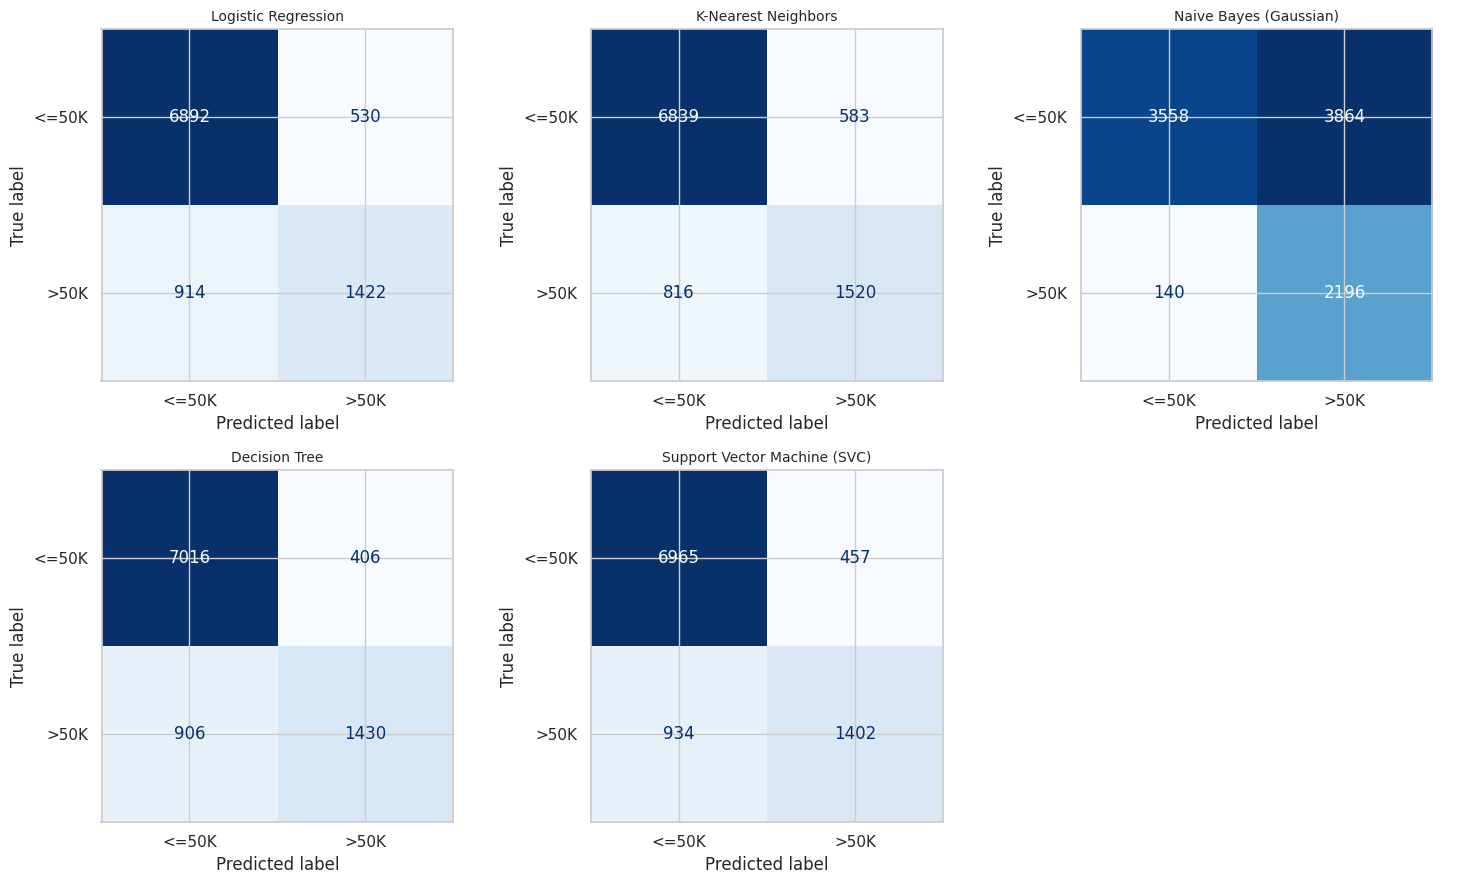

In [25]:
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
axes = axes.ravel()
cms = {'Logistic Regression': logreg_cm, 'K-Nearest Neighbors': knn_cm, 'Naive Bayes (Gaussian)': nb_cm,
       'Decision Tree': dt_cm, 'Support Vector Machine (SVC)': svc_cm}
for i, (name, cm) in enumerate(cms.items()):
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['<=50K','>50K'])
    disp.plot(ax=axes[i], colorbar=False, cmap='Blues')
    axes[i].set_title(name, fontsize=10)
axes[-1].axis('off')
plt.tight_layout()
plt.savefig('clf_confusion_matrices.png', bbox_inches='tight')
plt.show()

**Insight:** All five models show more false negatives (predicting `<=50K` for someone who actually earns `>50K`) than false
positives — a direct consequence of the class imbalance (models default toward the majority class when uncertain). Naive Bayes in
particular tends to show a very different error pattern from the rest (per its independence-assumption note above), often trading
precision for higher recall on the minority class or vice versa.

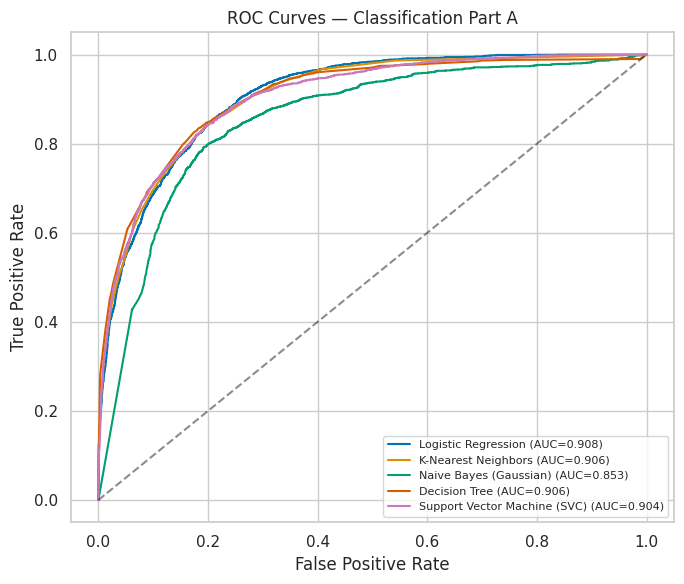

In [26]:
plt.figure(figsize=(7, 6))
proba_map = {'Logistic Regression': logreg_proba, 'K-Nearest Neighbors': knn_proba,
             'Naive Bayes (Gaussian)': nb_proba, 'Decision Tree': dt_proba, 'Support Vector Machine (SVC)': svc_proba}
for name, proba in proba_map.items():
    fpr, tpr, _ = roc_curve(y_test, proba)
    auc = roc_auc_score(y_test, proba)
    plt.plot(fpr, tpr, label=f'{name} (AUC={auc:.3f})')
plt.plot([0,1],[0,1],'k--', alpha=0.5)
plt.xlabel('False Positive Rate'); plt.ylabel('True Positive Rate')
plt.title('ROC Curves — Classification Part A')
plt.legend(fontsize=8)
plt.tight_layout()
plt.savefig('clf_roc_curves.png', bbox_inches='tight')
plt.show()

**Insight:** All five ROC curves sit well above the diagonal (no-skill) line, with Logistic Regression, SVC and Decision Tree
clustering closest to the top-left corner (highest AUC). Naive Bayes' curve is visibly the furthest from the others, consistent with
its violated independence assumption noted above producing less well-calibrated probability estimates.

## Section E — Summary

- All 5 required Classification Part-A algorithms were trained and evaluated on an identical stratified 80/20 split
  (`random_state=42`), preserving the ~76/24 class balance.
- Accuracy, weighted Precision/Recall/F1, confusion matrices, and ROC-AUC were reported for every algorithm in a single
  comparison table, satisfying the D2 evaluation requirement.
- KNN's *k* and the Decision Tree's `max_depth` were selected via cross-validation; SVC's kernel was chosen the same way
  on a documented stratified subsample (full-data SVC training is computationally impractical with an RBF kernel).
- The Decision Tree was visualised, and its top splits (`marital-status`, `capital_net`, `education-num`) align with
  well-known drivers of income in this dataset.

**Next step (Review 2 scope):** Classification Part B (Random Forest, AdaBoost, Gradient Boosting, Bagging, MLP), the consolidated
10-algorithm comparison table, and the full Clustering track.